
# **Fase 1: Perfilado  (Clustering)**

- **Input:** Dataset `mental_health.csv` 
- **Output** Dataset `perfil_usuario_mx.csv` (823 registros).
- **Proceso:** K-Means para agrupar en 3 perfiles (Bajo, Medio, Alto Riesgo).
- **Output:** El "Perfil Base" del usuario al iniciar el chat.

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('dataset/mental_health_finaldata_1.csv')
# --- PASO 1: Mapeo de Variables Ordinales (Orden Lógico) ---
# 'Mood_Swings' representa la escala de riesgo/estrés (Bajo, Medio, Alto).
# 'Age' y 'Days_Indoors' también tienen un orden que el modelo debe entender.
mood_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
age_mapping = {'16-20': 0, '20-25': 1, '25-30': 2, '30-Above': 3}
days_mapping = {
    'Go out Every day': 0, '1-14 days': 1, '15-30 days': 2, 
    '31-60 days': 3, 'More than 2 months': 4
}
# Mapeo para respuestas de intensidad (Yes=2, Maybe=1, No=0)
intensidad_map = {'Yes': 2, 'Maybe': 1, 'No': 0}

In [3]:
# Aplicamos las transformaciones
df['Mood_Swings'] = df['Mood_Swings'].map(mood_mapping)
df['Age'] = df['Age'].map(age_mapping)
df['Days_Indoors'] = df['Days_Indoors'].map(days_mapping)

In [4]:
# Columnas tipo Yes/Maybe/No
cols_intensidad = [
    'Growing_Stress', 'Quarantine_Frustrations', 'Changes_Habits', 
    'Mental_Health_History', 'Weight_Change', 'Coping_Struggles', 
    'Work_Interest', 'Social_Weakness'
]
for col in cols_intensidad:
    df[col] = df[col].map(intensidad_map)

In [5]:
# --- PASO 2: One-Hot Encoding (Variables Nominales) ---
#  columnas independientes para evitar sesgos jerárquicos.
df_final = pd.get_dummies(df, columns=['Gender', 'Occupation'], prefix=['Gen', 'Occ'])
#  booleanos resultantes a enteros (0 y 1)
df_final = df_final.astype(int)

In [ ]:
# --- PASO 3: Verificación y Exportación ---
print(f"Dataset procesado con éxito. Dimensiones: {df_final.shape}")
df_final.to_csv('dataset/perfil_usuario_mx.csv', index=False)

Dataset procesado con éxito. Dimensiones: (824, 18)


### Perfilado para el clustering
#### Agrupación de variables:
- **PHQ-9 (Depresión):**
  - Columnas `Mood_Swings`, `Changes_Habits` (sueño/hambre) y `Work_Interest` (anhedonia).
  - En el DSM-5, la pérdida de interés y el cambio de humor son criterios mayores para un episodio depresivo.

- **GAD-7 (Ansiedad):**
  - Columnas `Growing_Stress` y `Social_Weakness`.
  - El GAD-7 mide la preocupación constante y la tensión, en el dataset original de mental_health_finaldata se reflejan en el estrés creciente y la dificultad para socializar.
- **DSM-5:**
  - Coping_Struggles: Valida la incapacidad de lidiar con el estrés, un criterio de gravedad del DSM-5.

- **Factores de Riesgo:**
  - La columna `Mental_Health_History` es una "bandera roja".
  - Clínicamente, alguien con antecedentes tiene un umbral de riesgo más alto ante los mismos síntomas.
### Objetivo y preguntas asociadas:
  - ¿Es posible identificar grupos de riesgo (bajo, medio, alto) basándose únicamente en la similitud semántica de las conversaciones?
  - #3. Agrupamiento de Perfiles de Usuario: Segmentar a los usuarios por severidad de síntomas sin etiquetas previas.

1. Cargando y procesando datos clínicos...
2. Entrenando K-Means...
3. Generando Prueba Estadística (Boxplot)...


C:\Users\Asus Ryzen 5\AppData\Local\Temp\ipykernel_5128\1094409451.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


-> Guardada: 'separacion_estadistica_boxplot.png'
4. Generando Mapa de Islas (t-SNE)...
-> Guardada: 'separacion_islas_tsne.png'


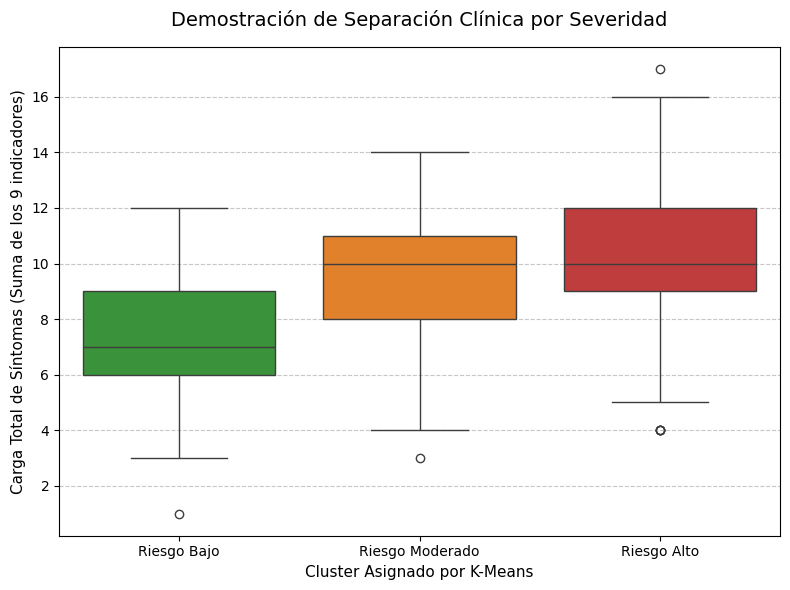

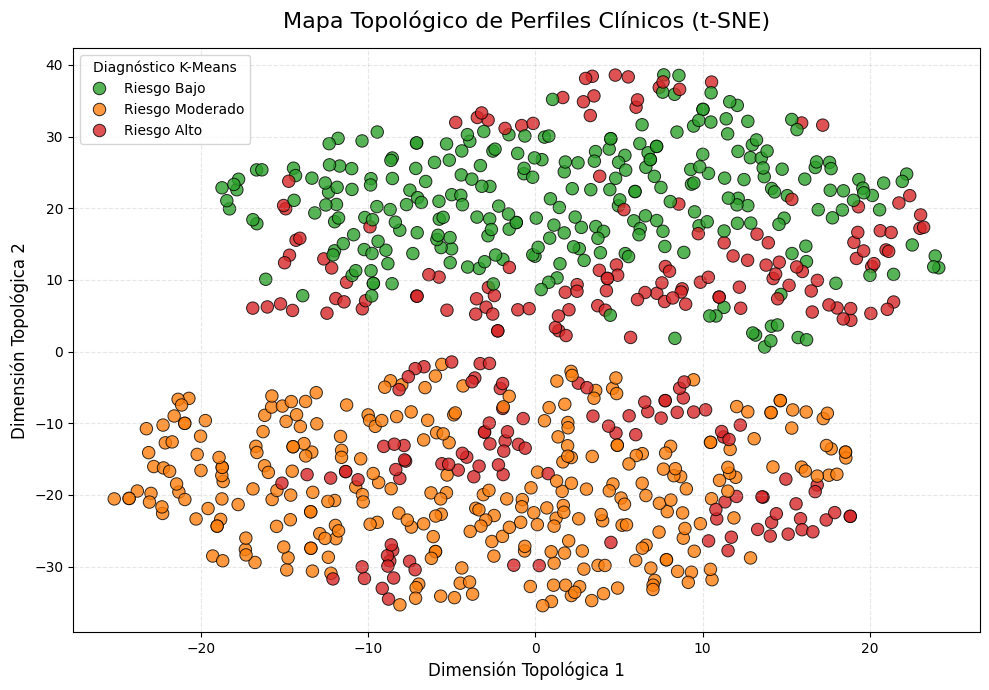

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import joblib

print("1. Cargando y procesando datos clínicos...")
df = pd.read_csv('dataset/perfil_usuario_mx.csv')

columnas_clinicas = [
    'Growing_Stress', 'Coping_Struggles', 'Work_Interest', 
    'Mood_Swings', 'Changes_Habits', 'Social_Weakness', 
    'Mental_Health_History', 'Quarantine_Frustrations', 'Weight_Change'
]

df_clinico = df[columnas_clinicas]
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clinico)

print("2. Entrenando K-Means...")
model_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = model_kmeans.fit_predict(df_scaled)

# Calcular Carga de Síntomas (Suma total)
df['Carga_Sintomas'] = df_clinico.sum(axis=1)
centros = df.groupby('Cluster')['Carga_Sintomas'].mean()

orden = centros.sort_values().index.tolist()
mapeo_nombres = {
    orden[0]: 'Riesgo Bajo',
    orden[1]: 'Riesgo Moderado',
    orden[2]: 'Riesgo Alto'
}
df['Nivel_Riesgo'] = df['Cluster'].map(mapeo_nombres)

joblib.dump(model_kmeans, 'modelos/modelo_clustering_v1.pkl')
joblib.dump(scaler, 'modelos/scaler_clustering.pkl')

# ==========================================
# GRÁFICA 1: LA PRUEBA ESTADÍSTICA (BOXPLOT)
# ==========================================
print("3. Generando Prueba Estadística (Boxplot)...")
plt.figure(figsize=(8, 6))
sns.boxplot(
    x='Nivel_Riesgo', y='Carga_Sintomas', data=df,
    order=['Riesgo Bajo', 'Riesgo Moderado', 'Riesgo Alto'],
    palette={'Riesgo Bajo': '#2ca02c', 'Riesgo Moderado': '#ff7f0e', 'Riesgo Alto': '#d62728'}
)
plt.title('Demostración de Separación Clínica por Severidad', fontsize=14, pad=15)
plt.ylabel('Carga Total de Síntomas (Suma de los 9 indicadores)', fontsize=11)
plt.xlabel('Cluster Asignado por K-Means', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('separacion_estadistica_boxplot.png', dpi=300)
print("-> Guardada: 'separacion_estadistica_boxplot.png'")

# ==========================================
# GRÁFICA 2: LA PRUEBA VISUAL (t-SNE)
# ==========================================
print("4. Generando Mapa de Islas (t-SNE)...")
# t-SNE desenreda las 9 dimensiones buscando agrupar los puntos similares
tsne = TSNE(n_components=2, perplexity=40, random_state=42)
componentes_tsne = tsne.fit_transform(df_scaled)

df['TSNE1'] = componentes_tsne[:, 0]
df['TSNE2'] = componentes_tsne[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='TSNE1', y='TSNE2', 
    hue='Nivel_Riesgo', 
    hue_order=['Riesgo Bajo', 'Riesgo Moderado', 'Riesgo Alto'],
    palette={'Riesgo Bajo': '#2ca02c', 'Riesgo Moderado': '#ff7f0e', 'Riesgo Alto': '#d62728'},
    data=df, alpha=0.8, edgecolor='k', s=80
)
plt.title('Mapa Topológico de Perfiles Clínicos (t-SNE)', fontsize=16, pad=15)
plt.xlabel('Dimensión Topológica 1', fontsize=12)
plt.ylabel('Dimensión Topológica 2', fontsize=12)
plt.legend(title='Diagnóstico K-Means', loc='best')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('separacion_islas_tsne.png', dpi=300)
print("-> Guardada: 'separacion_islas_tsne.png'")

##### Cálculo de silhouette e inertia
- Inertia: suma de distancias al cuadrado de cada punto a su centroide; se obtiene directamente de model.inertia_.
- Silhouette: mide cohesión vs separación; rango -1,1, valores cercanos a 1 indican clusters bien separados.



In [2]:
from sklearn.metrics import silhouette_score, silhouette_samples
# X_scaled: datos usados para clustering; labels: etiquetas KMeans
inertia = model_kmeans.inertia_
silhouette_avg = silhouette_score(df_scaled, df['Cluster'])
sample_silhouette_values = silhouette_samples(df_scaled, df['Cluster'])
print("Inertia:", inertia)
print("Silhouette promedio:", silhouette_avg)

Inertia: 6244.035206851552
Silhouette promedio: 0.08798563712536747



### 1. Escalas de las variables

| Variable                           | Rango | ¿Qué significa el valor?                                                   |
|------------------------------------|-------|----------------------------------------------------------------------------|
| Aislamiento (Days_Indoors)         | 0 a 4 | 0: Sale diario. 1: 1-14 días. 2: 15-30 días. 3: 31-60 días. 4: Más de 2 meses. |
| Síntomas (Estrés, Humor, etc.)     | 0 a 2 | 0: No / Bajo. 1: Tal vez / Moderado. 2: Sí / Alto.                          |
| Historial (historial)              | 0 a 2 | 0: No. 1: No sabe. 2: Sí.                                                  |
| Categoría de Edad (age_cat)        | 1 a 5 | 1: 16-20. 2: 21-25. 3: 26-30... (y así sucesivamente).                     |

### 2. Puntuación

- **puntuacion_real** = (estrés + interés + afrontamiento + humor + hábitos + debilidad_social)
- Cada una de estas 6 variables llega máximo a 2 → el tope de tu puntuación es **12**.
- Interpretación:
  - **6 o más** → Alerta clínica clara (**Riesgo Alto**).
  - **3 a 5** → **Riesgo Moderado**.
  - **0 a 2** → **Riesgo Bajo**.
- Nota: Si se ingresa un valor fuera de rango (ej. un 4 en estrés), el StandardScaler lo detectará como un outlier (valor atípico). Esto desvía el cálculo de distancia euclidiana de K-Means y puede clasificar erróneamente al usuario en un cluster opuesto o generar una predicción inconsistente.

- El cálculo de puntuacion_real no pretende ser un test diagnóstico PHQ-9 o GAD-7 oficial, ya que eso requeriría intervención humana médica. En su lugar, es un tamizaje rápido (Proxy Clínico) adaptado a un espacio vectorial de 0 a 2. Agrupa los síntomas base de anhedonia, estado de ánimo y respuestas de ansiedad en un rango máximo de 12 puntos, donde el umbral de 6 puntos (>50% de carga) dispara el protocolo de seguridad. Esto nos permite un perfilado algorítmico veloz y matemáticamente compatible con el K-Means, sin hacer diagnósticos médicos ilegales

In [18]:
import pandas as pd
import joblib

print("1. Cargando los cerebros matemáticos (Fase 1)...")
try:
    model_kmeans = joblib.load('modelos/modelo_clustering_v1.pkl')
    scaler = joblib.load('modelos/scaler_clustering.pkl')
    print("-> Modelos cargados correctamente.")
    
    # Identificamos dinámicamente qué cluster matemático es cuál sumando sus centros
    #MOTIVO-> asignacion aleatoria de etiquetas 
    # se extraen los centroides de cada grupi ( bajo,medio,alto)
    #.sum(axis=1) : suma a cada punto de los clusters , dando como resultado que el cluster "alto o riesgo" obtiene la mayor suma de sintomas
    sumas_centros = model_kmeans.cluster_centers_.sum(axis=1)
    #encuentran automaticamente que numero interno (0,1,2) tiene la suma mas alta y mas baja (menos riesgo , mayor riesgo)
    ID_VERDE = sumas_centros.argmin()
    ID_ROJO = sumas_centros.argmax()
    
except FileNotFoundError:
    print("ERROR: No se encontraron los archivos .pkl. Asegúrate de estar en la misma carpeta.")
    exit()

#
def puente_clinico_sin_sesgo(datos_usuario, scaler_cargado, kmeans_cargado, id_verde, id_rojo):
    """
    Función de Inferencia: 
    Recibe un perfil completo, pero aísla SOLO la sintomatología clínica para evitar 
    sesgos demográficos en el modelo de Machine Learning.
    """
    # 1. Definimos las únicas 9 variables que la IA tiene permitido ver
    cols_clinicas = [
        'Growing_Stress', 'Coping_Struggles', 'Work_Interest', 
        'Mood_Swings', 'Changes_Habits', 'Social_Weakness', 
        'Mental_Health_History', 'Quarantine_Frustrations', 'Weight_Change'
    ]
    
    # 2. FILTRO DE SESGO (Data Masking)
    # Extraemos los síntomas y dejamos la edad, género y ocupación fuera de la ecuación.
    reg = {
        'Growing_Stress': datos_usuario.get('estres', 0),
        'Coping_Struggles': datos_usuario.get('afrontamiento', 0),
        'Work_Interest': datos_usuario.get('interes', 0),
        'Mood_Swings': datos_usuario.get('humor', 0),
        'Changes_Habits': datos_usuario.get('habitos', 0),
        'Social_Weakness': datos_usuario.get('debilidad_social', 0),
        'Mental_Health_History': datos_usuario.get('historial', 0),
        'Quarantine_Frustrations': datos_usuario.get('irritabilidad', 0),
        'Weight_Change': datos_usuario.get('peso', 0)
    }
    
    # 3. PREDICCIÓN MATEMÁTICA PURA
    df_in = pd.DataFrame([reg], columns=cols_clinicas)
    df_in_scaled = scaler_cargado.transform(df_in)
    cluster_ia = kmeans_cargado.predict(df_in_scaled)[0]
    
    # 4. CAPA DE BLINDAJE (Reglas basadas exactamente en tu Imagen de puntuación)
    puntuacion_real = sum([
        reg['Growing_Stress'], reg['Coping_Struggles'], reg['Work_Interest'],
        reg['Mood_Swings'], reg['Changes_Habits'], reg['Social_Weakness']
    ])
    
    # RANGO 1: 0 a 2 puntos (Riesgo Bajo según tu regla)
    if puntuacion_real <= 2:
        # Solo sube a Moderado si tiene historial psiquiátrico (2) o la IA detectó peligro en otros síntomas
        if reg['Mental_Health_History'] == 2 or cluster_ia == id_rojo:
            return "RIESGO MODERADO"
        return "RIESGO BAJO"

    # RANGO 2: 3 a 5 puntos (Riesgo Moderado según tu regla)
    elif 3 <= puntuacion_real <= 5:
        # Solo sube a Alto si la IA lo mandó al cluster crítico o si tiene historial severo
        if cluster_ia == id_rojo or reg['Mental_Health_History'] == 2:
            return "RIESGO ALTO"
        return "RIESGO MODERADO"

    # RANGO 3: 6 o más puntos (Alerta Clínica Clara)
    else: 
        return "RIESGO ALTO"

    
# --- LOS 9 CASOS DE PRUEBA ---
casos_validación = [
    {"n": "1. Extremo (Grave)", "d": {'genero': 'femenino', 'aislamiento': 4, 'ocupacion': 'student', 'estres': 2, 'interes': 2, 'afrontamiento': 2, 'debilidad_social': 2, 'historial': 2, 'humor': 2, 'habitos': 2}},
    {"n": "2. Adulto en Crisis", "d": {'genero': 'masculino', 'age_cat': 3, 'aislamiento': 2, 'ocupacion': 'corporate', 'estres': 2, 'interes': 2, 'afrontamiento': 2, 'debilidad_social': 1, 'historial': 2, 'humor': 2, 'habitos': 2}},
    {"n": "3. Estudiante con Estrés", "d": {'genero': 'femenino', 'aislamiento': 0, 'ocupacion': 'student', 'estres': 1, 'interes': 0, 'afrontamiento': 1, 'debilidad_social': 0, 'historial': 0, 'humor': 0, 'habitos': 1}},
    {"n": "4. Persona Estable", "d": {'genero': 'masculino', 'aislamiento': 0, 'ocupacion': 'others', 'estres': 0, 'interes': 0, 'afrontamiento': 0, 'debilidad_social': 0, 'historial': 0, 'humor': 0, 'habitos': 0}},
    {"n": "5. Historial Crónico Estable", "d": {'genero': 'masculino', 'age_cat': 3, 'aislamiento': 0.5, 'ocupacion': 'corporate', 'estres': 0, 'interes': 0, 'afrontamiento': 0, 'debilidad_social': 0, 'historial': 2, 'humor': 0, 'habitos': 0, 'peso': 0, 'irritabilidad': 0}},
    {"n": "6. Aislamiento Social sin Síntomas", "d": {'genero': 'femenino', 'age_cat': 2, 'aislamiento': 4, 'ocupacion': 'others', 'estres': 0, 'interes': 0, 'afrontamiento': 0, 'debilidad_social': 1, 'historial': 0, 'humor': 0, 'habitos': 0, 'peso': 0, 'irritabilidad': 0}},
    {"n": "7. Burnout Laboral (Riesgo Medio)", "d": {'genero': 'femenino', 'age_cat': 4, 'aislamiento': 1, 'ocupacion': 'business', 'estres': 2, 'interes': 1, 'afrontamiento': 1, 'debilidad_social': 0, 'historial': 1, 'humor': 1, 'habitos': 2, 'peso': 1, 'irritabilidad': 2}},
    {"n": "8. Estudiante en Alerta Temprana", "d": {'genero': 'femenino', 'age_cat': 1, 'aislamiento': 0, 'ocupacion': 'student', 'estres': 1, 'interes': 2, 'afrontamiento': 1, 'debilidad_social': 2, 'historial': 0, 'humor': 1, 'habitos': 0, 'peso': 0, 'irritabilidad': 1}},
    {"n": "9. Estudiante mujer estable", "d": {'genero': 'femenino', 'age_cat': 1, 'aislamiento': 0, 'ocupacion': 'student', 'estres': 0, 'interes': 0, 'afrontamiento': 0, 'debilidad_social': 0, 'historial': 0, 'humor': 0, 'habitos': 0, 'peso': 0, 'irritabilidad': 0}},
       {"n": "10. Caso Real Fila 6 (Adolescente Aislada)", "d": {
        'genero': 'femenino', 
        'age_cat': 2,               # 16-20 años
        'ocupacion': 'student', 
        'aislamiento': 0,           # More than 2 months
        'estres': 1,                # Growing_Stress: Yes
        'irritabilidad': 1,         # Quarantine_Frustrations: Yes
        'habitos': 0,               # Changes_Habits: Yes
        'historial': 0,             # Mental_Health_History: No
        'peso': 1,                  # Weight_Change: Yes
        'humor': 1,                 # Mood_Swings: Medium
        'afrontamiento': 0,         # Coping_Struggles: Yes
        'interes': 0,               # Work_Interest: Maybe
        'debilidad_social': 0       # Social_Weakness: No
    }}
]

import json

print("\n--- RESULTADOS: VALIDACIÓN DE TRIAGE SIN SESGO ---")
for c in casos_validación:
    datos = c['d']
    resultado_riesgo = puente_clinico_sin_sesgo(datos, scaler, model_kmeans, ID_VERDE, ID_ROJO)

    print(f"[{c['n']}]")
    # Imprime todos los campos del diccionario 'datos'
    for k, v in datos.items():
        print(f"   {k}: {v}")
    print(f"   Veredicto del K-Means : {resultado_riesgo}\n")

1. Cargando los cerebros matemáticos (Fase 1)...
-> Modelos cargados correctamente.

--- RESULTADOS: VALIDACIÓN DE TRIAGE SIN SESGO ---
[1. Extremo (Grave)]
   genero: femenino
   aislamiento: 4
   ocupacion: student
   estres: 2
   interes: 2
   afrontamiento: 2
   debilidad_social: 2
   historial: 2
   humor: 2
   habitos: 2
   Veredicto del K-Means : RIESGO ALTO

[2. Adulto en Crisis]
   genero: masculino
   age_cat: 3
   aislamiento: 2
   ocupacion: corporate
   estres: 2
   interes: 2
   afrontamiento: 2
   debilidad_social: 1
   historial: 2
   humor: 2
   habitos: 2
   Veredicto del K-Means : RIESGO ALTO

[3. Estudiante con Estrés]
   genero: femenino
   aislamiento: 0
   ocupacion: student
   estres: 1
   interes: 0
   afrontamiento: 1
   debilidad_social: 0
   historial: 0
   humor: 0
   habitos: 1
   Veredicto del K-Means : RIESGO MODERADO

[4. Persona Estable]
   genero: masculino
   aislamiento: 0
   ocupacion: others
   estres: 0
   interes: 0
   afrontamiento: 0
   debili